# Analyze Gap between sim and real data

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import tqdm
sys.path.append('../src/utils/')
sys.path.append('../src/utils/IEBCS/')
import eventIO
import event_representations

In [2]:
# spike 5 spin 6 rec2 -> spin 6 sidespin 0
real_path = f"/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/roi/spike_5_spin_6_rec2_converted.hdf5"
sim_path = path_sim5 = f"/data/lkolmar/datasets/topspin_fit_to_max/preprocessed/{str(28).zfill(5)}/{str(28).zfill(5)}_roi.hdf5"

buf_real = eventIO.load_hdf5(real_path)
buf_sim = eventIO.load_hdf5(sim_path)

array_real = eventIO.buffer_to_array(buf_real)
array_sim = eventIO.buffer_to_array(buf_sim)

sequence_real = event_representations.create_sequence(array_real, time_window=5000, sensor_size=(100,100), flip=False)
sequence_sim = event_representations.create_sequence(array_sim, time_window=5000, sensor_size=(100,100), flip=True)

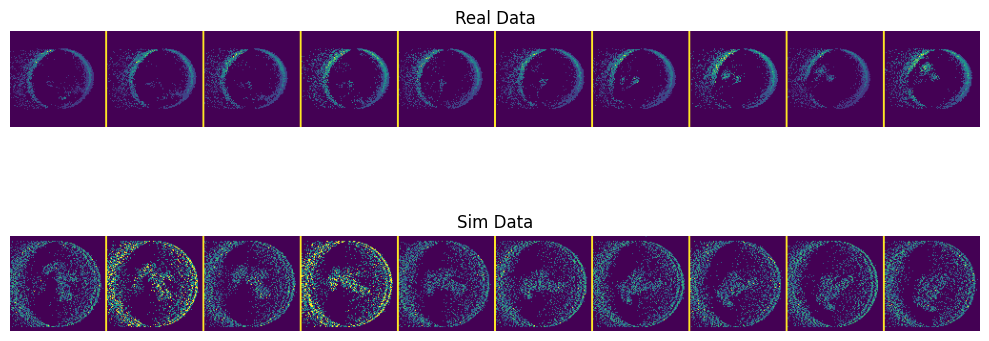

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10,5))
axes[0].imshow(event_representations.get_voxel_grid_as_image(sequence_real[5]))
axes[0].set_title("Real Data")
axes[0].axis('off')
axes[1].imshow(event_representations.get_voxel_grid_as_image(sequence_sim[10]))
axes[1].set_title("Sim Data")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Count total events

In [6]:
grid_real = sequence_real[5]
grid_sim = sequence_sim[10]
sum_real = [int(np.sum(grid_real[b])) for b in range(grid_real.shape[0])]
sum_sim = [int(np.sum(grid_sim[b])) for b in range(grid_sim.shape[0])]
print("Total events in real data:", np.sum(sum_real))
print("Total events in sim data:", np.sum(sum_sim))
print("Events per slice in real data:", sum_real)
print("Events per slice in sim data:", sum_sim)
print("Mean events per slice in real data:", np.mean(sum_real))
print("Mean events per slice in sim data:", np.mean(sum_sim))

Total events in real data: 1026030
Total events in sim data: 2760544
Events per slice in real data: [82025, 96339, 96900, 124950, 99246, 98736, 94911, 119085, 83980, 129858]
Events per slice in sim data: [257040, 368602, 251430, 377017, 242590, 257890, 252195, 250410, 252195, 251175]
Mean events per slice in real data: 102603.0
Mean events per slice in sim data: 276054.4


## Count logo events

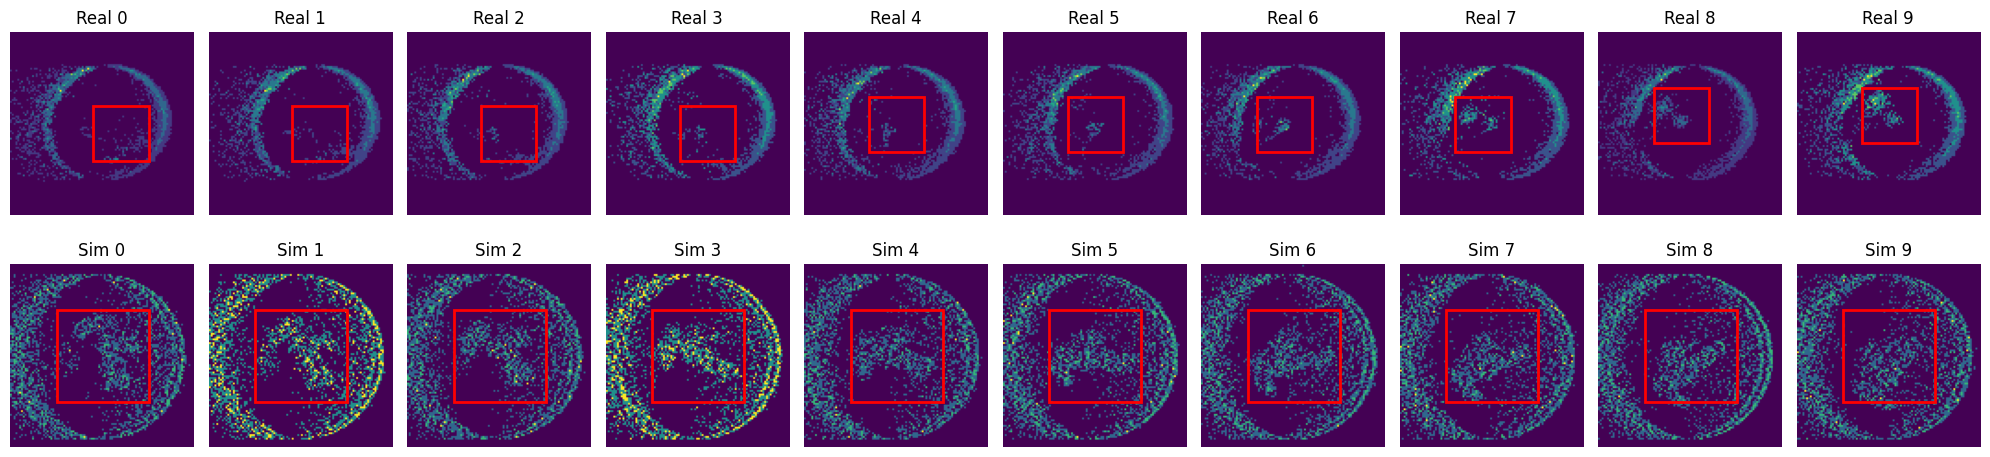

In [30]:
size = 50
sizes = [30, 30, 30, 30, 30, 30, 30, 30, 30, 30]
positions = [(45, 40), (45, 40), (40, 40), (40, 40), (35, 35), (35, 35), (30, 35), (30, 35), (30, 30), (35, 30)]
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for i in range(10):
    axes[0, i].imshow(grid_real[i])
    axes[0, i].add_patch(plt.Rectangle(
        positions[i], sizes[i], sizes[i], edgecolor='red', facecolor='none', linewidth=2
    ))
    axes[0, i].set_title(f"Real {i}")
    axes[0, i].axis('off')
    axes[1, i].imshow(grid_sim[i])
    axes[1, i].add_patch(plt.Rectangle(
        (50-(size//2), 50-(size//2)), size, size, edgecolor='red', facecolor='none', linewidth=2
    ))
    axes[1, i].set_title(f"Sim {i}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [32]:
counts_real = []
counts_sim = []
for i in range(10):
    logo_real = grid_real[i][positions[i][1]:positions[i][1]+sizes[i], positions[i][0]:positions[i][0]+sizes[i]]
    logo_sim = grid_sim[i][50-(size//2):50+(size//2), 50-(size//2):50+(size//2)]
    counts_real.append(int(np.sum(logo_real)))
    counts_sim.append(int(np.sum(logo_sim)))

print("Logo events in real data:", counts_real)
print("Logo events in sim data:", counts_sim)
print("Mean logo events in real data:", np.mean(counts_real))
print("Mean logo events in sim data:", np.mean(counts_sim))

Logo events in real data: [4377, 3723, 3621, 3442, 3417, 4080, 6171, 12240, 8967, 17340]
Logo events in sim data: [58395, 85297, 58480, 83895, 54910, 58480, 59670, 58225, 57205, 53975]
Mean logo events in real data: 6737.8
Mean logo events in sim data: 62853.2


In [33]:
print("Ratio logo/total real data:", np.mean(counts_real)/np.mean(sum_real))
print("Ratio logo/total sim data:", np.mean(counts_sim)/np.mean(sum_sim))

Ratio logo/total real data: 0.06566864516632068
Ratio logo/total sim data: 0.22768410863945654


## Count duration

In [44]:
path = "/home/lkolmar/Documents/metavision/recordings/dataset_full_ball-gun/roi/"
filenames = [path + f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
durations_real = []
for filename in tqdm.tqdm(filenames):
    buf = eventIO.load_hdf5(filename)
    durations_real.append(buf.get_ts().max() - buf.get_ts().min())

path = "/data/lkolmar/datasets/topspin_fit_to_max/preprocessed/"
filenames = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
durations_sim = []
for dirname in tqdm.tqdm(filenames):
    buf = eventIO.load_hdf5(os.path.join(path, dirname, f"{dirname}_roi.hdf5"))
    durations_sim.append(buf.get_ts().max() - buf.get_ts().min())

100%|██████████| 1848/1848 [02:35<00:00, 11.90it/s]


In [47]:
print("Average duration real data (s):", np.mean(durations_real)/1e6)
print("Average duration sim data (s):", np.mean(durations_sim)/1e6)
print("Std duration real data (s):", np.std(durations_real)/1e6)
print("Std duration sim data (s):", np.std(durations_sim)/1e6)

Average duration real data (s): 0.15017615384615385
Average duration sim data (s): 0.1489402002164502
Std duration real data (s): 0.020826160702987984
Std duration sim data (s): 0.029267615130025668
